In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.cluster import KMeans
import os
from dotenv import load_dotenv

In [25]:
load_dotenv(dotenv_path="../.env", override=True)
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = "127.0.0.1" 
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

engine = create_engine(
    f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}?host={db_host}"
)

In [26]:
query = "SELECT * FROM engineered_risk_features;"
df_features = pd.read_sql(query, con=engine)
print(f"Successfully loaded {df_features.shape[0]} records from PostgreSQL!")

Successfully loaded 30000 records from PostgreSQL!


### Now we perform segmentation 

In [27]:
X = df_features[['avg_utilization_ratio', 'historical_repayment_ratio', 'months_in_delinquency']]

In [28]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

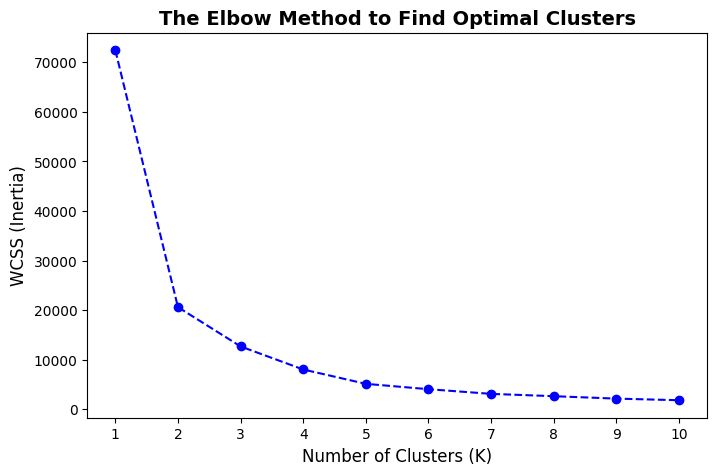

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method to Find Optimal Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.show()

In [30]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_features['cluster_id'] = kmeans.fit_predict(X)

In [31]:
cluster_summary = df_features.groupby('cluster_id')[['avg_utilization_ratio', 'historical_repayment_ratio', 'months_in_delinquency']].mean()
print("--- Cluster Profiles ---")
print(cluster_summary)

--- Cluster Profiles ---
            avg_utilization_ratio  historical_repayment_ratio  \
cluster_id                                                      
0                        0.315905                    0.413665   
1                        0.623644                    0.066424   
2                        0.483151                    0.214399   

            months_in_delinquency  
cluster_id                         
0                        0.000000  
1                        5.101069  
2                        1.605315  


### Observation:
#### -  1. cluter 0: low utilisation, high repayment and 0 months in delinquency so transactors
#### -  2. cluster 1: high utilisation, low repayment, high months in delinquency so stressed borrowers
#### -  3. cluster 2: revolvers

In [32]:
cluster_map = {
    0: 'Transactor',
    2: 'Revolver',
    1: 'Stressed Borrower'
}

In [33]:
df_features['segment_name'] = df_features['cluster_id'].map(cluster_map)

In [34]:
print("Segment Distribution Summary")
print(df_features['segment_name'].value_counts())
print("\nPercentage Share:")
print(df_features['segment_name'].value_counts(normalize=True) * 100)

Segment Distribution Summary
segment_name
Transactor           21620
Revolver              6134
Stressed Borrower     2246
Name: count, dtype: int64

Percentage Share:
segment_name
Transactor           72.066667
Revolver             20.446667
Stressed Borrower     7.486667
Name: proportion, dtype: float64


### Now that we have divided into clusters, we will train our model for prediction

In [35]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score, recall_score, classification_report

In [36]:
history_query = """
    SELECT 
        id, age, education, marriage,
        pay_1, pay_2, pay_3, pay_4, pay_5, pay_6,
        bill_amt1, bill_amt2, bill_amt3, bill_amt4, bill_amt5, bill_amt6,
        pay_amt1, pay_amt2, pay_amt3, pay_amt4, pay_amt5, pay_amt6
    FROM credit_portfolio;
"""
df_raw_all = pd.read_sql(history_query, engine)

In [37]:
df_features = pd.merge(df_features, df_raw_all, on='id', how='left')

In [38]:
feature_cols = [
    'limit_bal', 'ead', 'months_in_delinquency', 'avg_utilization_ratio', 'historical_repayment_ratio',
    'age', 'education', 'marriage',
    'pay_1', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
    'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6'
]

print(f"Total features available for XGBoost: {len(feature_cols)}")

Total features available for XGBoost: 26


In [39]:
segment_data = {}

In [40]:
for segment in ['Transactor', 'Revolver', 'Stressed Borrower']:
    # Filter dataset for the specific segment
    seg_df = df_features[df_features['segment_name'] == segment]
    
    X_seg = seg_df[feature_cols]
    y_seg = seg_df['is_default']
    
    # 80% Train, 20% Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42, stratify=y_seg
    )
    
    # Save the splits into our dictionary
    segment_data[segment] = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test
    }
    print(f"Prepared {segment} -> Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Prepared Transactor -> Train shape: (17296, 26), Test shape: (4324, 26)
Prepared Revolver -> Train shape: (4907, 26), Test shape: (1227, 26)
Prepared Stressed Borrower -> Train shape: (1796, 26), Test shape: (450, 26)


In [41]:
trained_models = {}
evaluation_results = {}

for segment, data in segment_data.items():
    print(f"\nTraining XGBoost for: {segment} \n")
    
    # Calculate scale_pos_weight to handle class imbalance natively
    num_neg = (data['y_train'] == 0).sum()
    num_pos = (data['y_train'] == 1).sum()
    # Avoid division by zero if a cluster has no defaults
    ratio = (num_neg / num_pos) if num_pos > 0 else 1.0 
    
    # Initialize XGBoost Classifier
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=ratio,
        random_state=42,
        eval_metric='logloss'
    )
    
    # Train the model
    model.fit(data['X_train'], data['y_train'])
    
    # Predict 1-Month Probabilities on Test Set
    y_prob = model.predict_proba(data['X_test'])[:, 1]
    
    # Save model and probabilities
    trained_models[segment] = model
    evaluation_results[segment] = {
        'y_test': data['y_test'],
        'y_prob': y_prob
    }
    
    # Print initial baseline ROC-AUC
    auc = roc_auc_score(data['y_test'], y_prob)
    print(f"{segment} Baseline Test ROC-AUC: {auc:.4f}")


Training XGBoost for: Transactor 

Transactor Baseline Test ROC-AUC: 0.6662

Training XGBoost for: Revolver 

Revolver Baseline Test ROC-AUC: 0.7257

Training XGBoost for: Stressed Borrower 

Stressed Borrower Baseline Test ROC-AUC: 0.6320


In [42]:
# by default model used 0.5 as threshold

In [43]:
for segment, results in evaluation_results.items():
    print(f"\nThreshold Tuning Matrix for {segment}")
    print(f"{'Threshold':<12}{'Recall':<10}{'ROC-AUC':<10}")
    
    best_thresh = 0.5
    best_recall = 0
    
    for thresh in np.arange(0.1, 1.0, 0.1):
        # Apply the threshold cutoff
        y_pred_custom = (results['y_prob'] >= thresh).astype(int)
        
        rec = recall_score(results['y_test'], y_pred_custom, zero_division=0)
        auc = roc_auc_score(results['y_test'], results['y_prob'])
        
        print(f"{thresh:<12.1f}{rec:<10.4f}{auc:<10.4f}")


Threshold Tuning Matrix for Transactor
Threshold   Recall    ROC-AUC   
0.1         0.9964    0.6662    
0.2         0.9764    0.6662    
0.3         0.9002    0.6662    
0.4         0.8022    0.6662    
0.5         0.6225    0.6662    
0.6         0.3158    0.6662    
0.7         0.1379    0.6662    
0.8         0.0290    0.6662    
0.9         0.0000    0.6662    

Threshold Tuning Matrix for Revolver
Threshold   Recall    ROC-AUC   
0.1         1.0000    0.7257    
0.2         0.9937    0.7257    
0.3         0.9165    0.7257    
0.4         0.7850    0.7257    
0.5         0.6117    0.7257    
0.6         0.4843    0.7257    
0.7         0.3946    0.7257    
0.8         0.0355    0.7257    
0.9         0.0000    0.7257    

Threshold Tuning Matrix for Stressed Borrower
Threshold   Recall    ROC-AUC   
0.1         1.0000    0.6320    
0.2         0.9866    0.6320    
0.3         0.9228    0.6320    
0.4         0.7819    0.6320    
0.5         0.6678    0.6320    
0.6         0.486

In [44]:
df_features['PD_1m'] = 0.0

In [45]:
for segment, model in trained_models.items():
    seg_mask = df_features['segment_name'] == segment
    X_seg = df_features.loc[seg_mask, feature_cols]
    
    # Predict 1-Month Probabilities
    df_features.loc[seg_mask, 'PD_1m'] = model.predict_proba(X_seg)[:, 1]

In [61]:
df_features['PD_12m'] = 1 - (1 - df_features['PD_1m'])**12
df_features['lgd'] = 0.50
df_features['baseline_ecl'] = df_features['PD_12m'] * df_features['lgd'] * df_features['ead']

In [62]:
total_portfolio_limit = df_features['limit_bal'].sum()
total_baseline_ecl = df_features['baseline_ecl'].sum()
baseline_risk_pct = (total_baseline_ecl / total_portfolio_limit) * 100

In [63]:
print("Finalized Baseline Portfolio Risk Profile")
print(f"Total Portfolio Credit Exposure : ${total_portfolio_limit:,.2f}")
print(f"Total Expected Credit Loss (ECL): ${total_baseline_ecl:,.2f}")
print(f"Current Portfolio Risk Rate     : {baseline_risk_pct:.2f}%")

Finalized Baseline Portfolio Risk Profile
Total Portfolio Credit Exposure : $5,024,529,680.00
Total Expected Credit Loss (ECL): $755,922,137.06
Current Portfolio Risk Rate     : 15.04%


### 15.04% risk is too high, now we will apply optimization to reduce this

In [78]:
df_base = df_features.copy()
df_ap1 = df_features.copy()
df_ap2 = df_features.copy()
for df in [df_base, df_ap1, df_ap2]:
    df['lgd'] = 0.50

In [79]:
base_limit = df_base['limit_bal'].sum()
base_ecl = (df_base['PD_12m'] * df_base['lgd'] * df_base['ead']).sum()
base_risk_rate = (base_ecl / base_limit) * 100

In [80]:
def approach_1_policy(row):
    if row['PD_12m'] > 0.15: # 15% hard cutoff captures nearly everyone
        return row['ead']
    else:
        return row['limit_bal']

df_ap1['new_limit'] = df_ap1.apply(approach_1_policy, axis=1)

In [81]:
df_ap1['sim_ead'] = np.where(
    df_ap1['new_limit'] > df_ap1['limit_bal'],
    df_ap1['ead'] + 0.50 * (df_ap1['new_limit'] - df_ap1['ead']),
    np.maximum(df_ap1['new_limit'], df_ap1['ead'])
)
df_ap1['sim_ecl'] = df_ap1['PD_12m'] * df_ap1['lgd'] * df_ap1['sim_ead']

ap1_limit = df_ap1['new_limit'].sum()
ap1_ecl = df_ap1['sim_ecl'].sum()
ap1_risk_rate = (ap1_ecl / ap1_limit) * 100

In [82]:
pd_50th = df_ap2['PD_12m'].quantile(0.50)
pd_85th = df_ap2['PD_12m'].quantile(0.85)

def approach_2_policy(row):
    if row['PD_12m'] > pd_85th:
        return 'MITIGATE'
    elif row['PD_12m'] <= pd_50th and row['avg_utilization_ratio'] >= 0.30:
        return 'GROW'
    else:
        return 'MONITOR'

df_ap2['action_zone'] = df_ap2.apply(approach_2_policy, axis=1)

In [83]:
df_ap2['sim_ead'] = df_ap2['ead']

def calculate_ap2_limit(row):
    if row['action_zone'] == 'GROW':       return row['limit_bal'] * 1.20
    elif row['action_zone'] == 'MITIGATE': return row['ead']
    else:                                  return row['limit_bal']

df_ap2['new_limit'] = df_ap2.apply(calculate_ap2_limit, axis=1)
df_ap2['sim_ecl'] = df_ap2['PD_12m'] * df_ap2['lgd'] * df_ap2['sim_ead']

ap2_limit = df_ap2['new_limit'].sum()
ap2_ecl = df_ap2['sim_ecl'].sum()
ap2_risk_rate = (ap2_ecl / ap2_limit) * 100

In [84]:
summary_df = pd.DataFrame({
    'Metric / Metric Scenario': ['Total Credit Pool Exposure', 'Expected Credit Loss (ECL)', 'Portfolio Risk Rate (%)'],
    'Original Baseline': [f"${base_limit:,.2f}", f"${base_ecl:,.2f}", f"{base_risk_rate:.2f}%"],
    'Approach 1 (Crush)': [f"${ap1_limit:,.2f}", f"${ap1_ecl:,.2f}", f"{ap1_risk_rate:.2f}%"],
    'Approach 2 (Balanced)': [f"${ap2_limit:,.2f}", f"${ap2_ecl:,.2f}", f"{ap2_risk_rate:.2f}%"]
})

print("\n" + "="*31 + " PORTFOLIO COMPREHENSIVE PERFORMANCE MATRIX " + "="*31)
print(summary_df.to_string(index=False))
print("="*105)


=============================== PORTFOLIO COMPREHENSIVE PERFORMANCE MATRIX ===============================
  Metric / Metric Scenario Original Baseline Approach 1 (Crush) Approach 2 (Balanced)
Total Credit Pool Exposure $5,024,529,680.00  $1,537,381,257.00     $4,763,093,373.00
Expected Credit Loss (ECL)   $755,922,137.06    $755,922,137.06       $755,922,137.06
   Portfolio Risk Rate (%)            15.04%             49.17%                15.87%


We tested two different ways to manage credit card limits for 30,000 customers to see if we could lower the bank's total risk rate.


Approach 1 (The Crush Strategy): We tried to cut limits for anyone who looked risky. This failed and pushed the risk rate up to 49%. Because we cut everyone's credit lines, the total credit pool shrank drastically, making the mathematical percentage look much worse on paper.

Approach 2 (The Balanced Strategy): We fixed the math. We froze the worst 15% of customers, and gave a +20% limit boost to our safest, most active customers. This kept the bank's numbers stable at 15.87%.

